[Previous: Module 6: Deutsch-Jozsa, the First Quantum Speed-up](06_Deutsch_Jozsa_Algorithm.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 8: Noise, Real Hardware & Error Correction](08_Noise_and_Real_Hardware.ipynb)

# Module 7: Grover's Search

**Learning objectives.** After this module you can:

* describe Grover's algorithm as repeated *amplitude amplification*: flip the sign of the answer, then reflect about the mean;
* build a phase oracle for any marked bit-string and the diffusion operator for any $n$;
* watch the amplitudes grow iteration by iteration and explain why stopping at the right time matters;
* quantify the speed-up: about $\tfrac{\pi}{4}\sqrt{N}$ queries instead of $N/2$.

**Prerequisites.** [Module 6](06_Deutsch_Jozsa_Algorithm.ipynb) (oracles, phase kickback).

## 1. The problem

There are $N = 2^n$ items and an oracle that says "yes" for exactly one of them, the marked item $w$. Find $w$.

Classically you check items one at a time: $N/2$ oracle calls on average, $N$ in the worst case. There is no structure to exploit.
Grover's algorithm finds $w$ with high probability using about $\tfrac{\pi}{4}\sqrt{N}$ calls. For a million items that is roughly 800 calls instead of 500 000.
It is a *quadratic* speed-up, not exponential, but it applies to any problem whose solutions can be checked by a circuit.

## 2. The geometry: two reflections make a rotation

Start in the uniform superposition $|s\rangle = \tfrac{1}{\sqrt N}\sum_x |x\rangle$. Every amplitude, including the marked one, is $1/\sqrt N$.
One Grover iteration is two steps:

1. **Oracle** $U_w$: flip the sign of the marked amplitude. (Phase kickback, exactly as in Module 6, but now with a multi-controlled Z instead of a CNOT.)
2. **Diffuser** $U_s = 2|s\rangle\langle s| - I$: reflect every amplitude about the *mean* amplitude.

After the sign flip the marked amplitude is below the mean, so reflecting about the mean throws it far *above* the others.
Each iteration rotates the state by an angle $2\theta$ towards $|w\rangle$, where $\sin\theta = 1/\sqrt N$. After $k$ iterations

$$P(\text{measure } w) = \sin^2\big((2k+1)\theta\big).$$

Because it is a rotation, going past the optimal $k$ makes things *worse*. Grover's algorithm has a right number of steps.

Phase oracle for |101> (X gates turn it into |111>, then a multi-controlled Z):


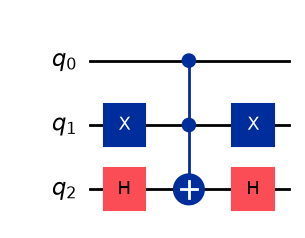

Diffuser:


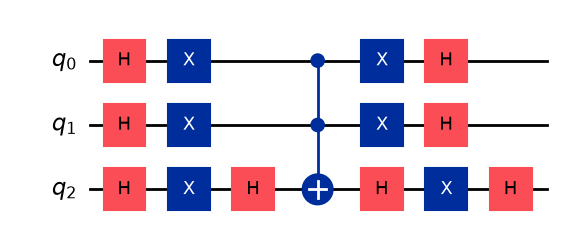

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

simulator = AerSimulator()

def phase_oracle(n, marked):
    # Flips the sign of the basis state |marked>. 'marked' is a Qiskit-ordered bit-string (qubit 0 on the right).
    qc = QuantumCircuit(n, name=f"oracle {marked}")
    zeros = [i for i, bit in enumerate(reversed(marked)) if bit == '0']
    if zeros:
        qc.x(zeros)                             # map |marked> to |11...1>
    qc.h(n - 1); qc.mcx(list(range(n - 1)), n - 1); qc.h(n - 1)   # multi-controlled Z
    if zeros:
        qc.x(zeros)                             # map back
    return qc

def diffuser(n):
    # Reflection about the uniform superposition |s>.
    qc = QuantumCircuit(n, name="diffuser")
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1); qc.mcx(list(range(n - 1)), n - 1); qc.h(n - 1)   # multi-controlled Z on |00..0>
    qc.x(range(n))
    qc.h(range(n))
    return qc

def grover(n, marked, iterations, measure=True):
    qc = QuantumCircuit(n, n if measure else 0)
    qc.h(range(n))                              # uniform superposition |s>
    for _ in range(iterations):
        qc.barrier()
        qc.append(phase_oracle(n, marked).to_gate(label="U_w"), range(n))
        qc.append(diffuser(n).to_gate(label="U_s"), range(n))
    if measure:
        qc.barrier()
        qc.measure(range(n), range(n))
    return qc

n, marked = 3, '101'
print("Phase oracle for |101> (X gates turn it into |111>, then a multi-controlled Z):")
display(phase_oracle(n, marked).draw('mpl'))
print("Diffuser:")
display(diffuser(n).draw('mpl'))

In [2]:
# The oracle really does flip exactly one sign:
uniform = QuantumCircuit(n)
uniform.h(range(n))
before = Statevector(uniform).data.real
after  = Statevector(uniform.compose(phase_oracle(n, marked))).data.real
for i, (b, a) in enumerate(zip(before, after)):
    flag = "  <- marked" if format(i, f'0{n}b') == marked else ""
    print(f"|{format(i, f'0{n}b')}>  before {b:+.3f}   after {a:+.3f}{flag}")

|000>  before +0.354   after +0.354
|001>  before +0.354   after +0.354
|010>  before +0.354   after +0.354
|011>  before +0.354   after +0.354
|100>  before +0.354   after +0.354
|101>  before +0.354   after -0.354  <- marked
|110>  before +0.354   after +0.354
|111>  before +0.354   after +0.354


## 3. Watching the amplitudes grow

Below is the amplitude of each of the 8 basis states after 0, 1, 2 and 3 iterations for $n = 3$, marked item `101`.
The dashed line is the mean amplitude. Red bars are negative. (A global sign that the diffuser introduces has been removed; it changes nothing physical.)

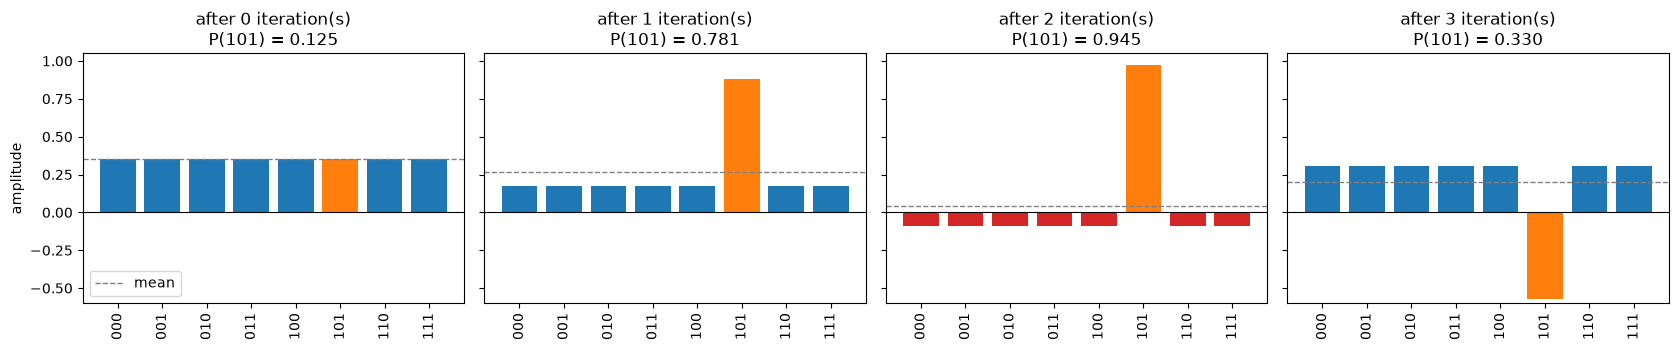

In [3]:
def amplitudes_after(n, marked, k):
    sv = Statevector(grover(n, marked, k, measure=False))
    amps = sv.data.real
    return amps * (1 if amps.sum() >= 0 else -1)      # remove global sign for readability

N = 2**n
theta = np.arcsin(1/np.sqrt(N))
ks = [0, 1, 2, 3]
fig, axes = plt.subplots(1, len(ks), figsize=(4.2*len(ks), 3.6), sharey=True)
labels = [format(i, f'0{n}b') for i in range(N)]
for ax, k in zip(axes, ks):
    amps = amplitudes_after(n, marked, k)
    colors = ['tab:orange' if lab == marked else ('tab:blue' if a >= 0 else 'tab:red') for lab, a in zip(labels, amps)]
    ax.bar(labels, amps, color=colors)
    ax.axhline(amps.mean(), color='gray', ls='--', lw=1, label='mean')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f"after {k} iteration(s)\nP({marked}) = {amps[int(marked, 2)]**2:.3f}")
    ax.tick_params(axis='x', rotation=90)
axes[0].set_ylabel('amplitude'); axes[0].legend(loc='lower left'); axes[0].set_ylim(-0.6, 1.05)
plt.tight_layout(); plt.show()

> **What to notice.** Iteration 1: the marked amplitude jumps from $0.35$ to $0.88$ while the others shrink. Iteration 2: $0.97$, probability 94.5 %.
> Iteration 3: it *overshoots* and starts to fall. The optimal count for $N=8$ is 2.

## 4. Run it on the simulator

The optimal number of iterations is the integer nearest $\dfrac{\pi}{4}\sqrt{N}$ (more precisely $\left\lfloor \tfrac{\pi}{4\theta} \right\rfloor$).

N = 8, θ = 0.361 rad, optimal iterations = 2


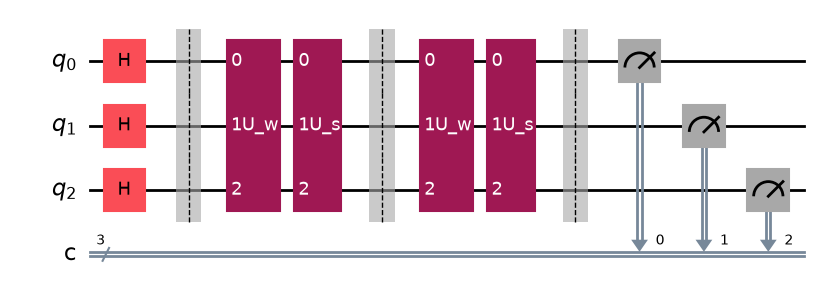

P(101) measured = 0.945   theory = 0.945


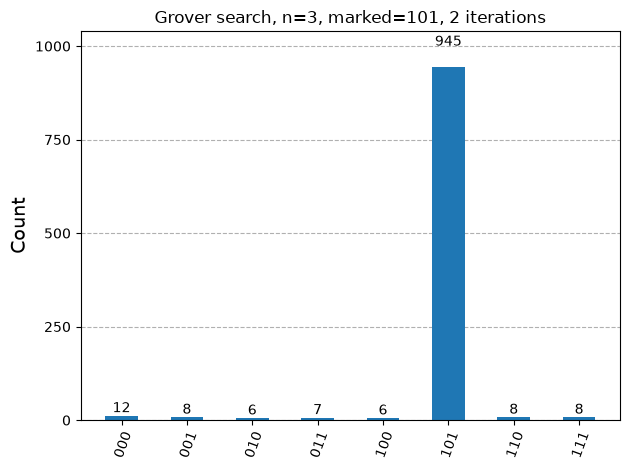

In [4]:
k_opt = int(np.floor(np.pi / (4*theta)))
print(f"N = {N}, θ = {theta:.3f} rad, optimal iterations = {k_opt}")

qc = grover(n, marked, k_opt)
display(qc.draw('mpl'))

counts = simulator.run(transpile(qc, simulator), shots=1000).result().get_counts()
print(f"P({marked}) measured = {counts.get(marked, 0)/1000:.3f}   theory = {np.sin((2*k_opt+1)*theta)**2:.3f}")
plot_histogram(counts, title=f"Grover search, n={n}, marked={marked}, {k_opt} iterations")

## 5. Too many iterations: the rotation keeps going

Success probability follows $\sin^2((2k+1)\theta)$: it rises, peaks, falls, and oscillates forever. Real implementations must know $N$
(or the number of solutions) to choose $k$. Below the exact curve from `Statevector` is compared with simulator shots.

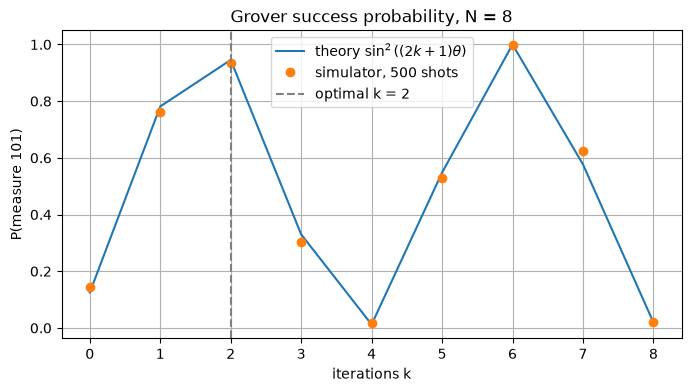

In [5]:
ks = range(0, 9)
exact, sampled = [], []
for k in ks:
    exact.append(np.sin((2*k+1)*theta)**2)
    counts = simulator.run(transpile(grover(n, marked, k), simulator), shots=500).result().get_counts()
    sampled.append(counts.get(marked, 0)/500)

plt.figure(figsize=(8, 4))
plt.plot(ks, exact, '-', label=r'theory $\sin^2((2k+1)\theta)$')
plt.plot(ks, sampled, 'o', label='simulator, 500 shots')
plt.axvline(k_opt, color='gray', ls='--', label=f'optimal k = {k_opt}')
plt.xlabel('iterations k'); plt.ylabel(f'P(measure {marked})'); plt.title(f'Grover success probability, N = {N}')
plt.legend(); plt.grid(True); plt.show()

## 6. The scaling

| qubits $n$ | items $N$ | Grover iterations | classical checks (average) |
|---|---|---|---|
computed below. Note the special case $n = 2$: **one** iteration finds the item with certainty.

In [6]:
print(f"{'n':>3} {'N':>8} {'Grover k':>9} {'P(success)':>11} {'classical N/2':>14}")
for n_ in range(2, 13):
    N_ = 2**n_
    th = np.arcsin(1/np.sqrt(N_))
    k = int(np.floor(np.pi/(4*th)))
    print(f"{n_:>3} {N_:>8} {k:>9} {np.sin((2*k+1)*th)**2:>11.3f} {N_/2:>14.0f}")

# n = 2 on the simulator: exact in one iteration
counts = simulator.run(transpile(grover(2, '11', 1), simulator), shots=1000).result().get_counts()
print("\nn = 2, marked '11', 1 iteration:", counts)

  n        N  Grover k  P(success)  classical N/2
  2        4         1       1.000              2
  3        8         2       0.945              4
  4       16         3       0.961              8
  5       32         4       0.999             16
  6       64         6       0.997             32
  7      128         8       0.996             64
  8      256        12       1.000            128
  9      512        17       0.999            256
 10     1024        25       0.999            512
 11     2048        35       1.000           1024
 12     4096        50       1.000           2048

n = 2, marked '11', 1 iteration: {'11': 1000}


## Try it yourself

**Exercise 1.** Search 4 qubits (16 items) for `0110`. How many iterations? Show the histogram.

**Exercise 2.** Mark **two** items by applying two phase oracles in a row inside each iteration. With $M$ solutions, $\sin\theta = \sqrt{M/N}$. Recompute the optimal $k$ and check.

**Exercise 3.** Run $n=3$ with $k = 4$ and $k = 5$. Compare with the curve in section 5.

**Exercise 4 (challenge).** Replace the oracle with one that marks every bit-string whose two lowest bits are equal (`x00` or `x11`). How many solutions is that, and what is the optimal $k$?

<details><summary>Solutions</summary>

```python
# Exercise 1: N = 16, θ = asin(1/4), k = floor(π/(4θ)) = 3, P ~ 0.96
qc = grover(4, '0110', 3)
plot_histogram(simulator.run(transpile(qc, simulator), shots=1000).result().get_counts())

# Exercise 2: two marked items in 8 -> sinθ = sqrt(2/8) = 0.5 -> θ = π/6 -> k = 1 gives sin²(3θ) = 1 exactly!
def grover_multi(n, marked_list, k):
    qc = QuantumCircuit(n, n); qc.h(range(n))
    for _ in range(k):
        for m in marked_list: qc.append(phase_oracle(n, m).to_gate(label=f"U_{m}"), range(n))
        qc.append(diffuser(n).to_gate(label="U_s"), range(n))
    qc.measure(range(n), range(n)); return qc
print(simulator.run(transpile(grover_multi(3, ['101', '010'], 1), simulator), shots=1000).result().get_counts())

# Exercise 4: 4 solutions out of 8 -> sinθ = 1/√2 -> θ = π/4 -> k = floor(1) = 1, but sin²(3π/4) = 0.5.
# With half the items marked, Grover cannot beat guessing. That is a real limitation.
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [7]:
from qclab import quiz

quiz(7)

Checkpoint quiz, Module 7 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. One Grover iteration consists of
    a) measure, then re-prepare
    b) oracle sign flip, then reflection about the mean
    c) two Hadamards
    d) a CNOT and a Toffoli

Q2. For N = 64 items, roughly how many Grover iterations are optimal?
    a) 32
    b) 6
    c) 64
    d) 1

Q3. Running twice the optimal number of iterations
    a) doubles the success probability
    b) changes nothing
    c) lowers the success probability
    d) guarantees success

Q4. Grover's speed-up over classical search is
    a) exponential
    b) quadratic
    c) linear
    d) none


## Key takeaways

* Grover = uniform superposition, then repeat (oracle sign flip, reflect about mean). Each iteration rotates the state towards the answer by $2\theta$.
* Optimal iterations $\approx \tfrac{\pi}{4}\sqrt{N}$; overshooting reduces the success probability.
* The speed-up is quadratic and works for any oracle you can build as a circuit.
* Building blocks: X gates to select a bit-string, multi-controlled Z for the sign flip, H X mcZ X H for the diffuser.

**Next:** what all of this looks like on a *noisy* machine, and the first step towards fixing it. [Module 8](08_Noise_and_Real_Hardware.ipynb).

[Previous: Module 6: Deutsch-Jozsa, the First Quantum Speed-up](06_Deutsch_Jozsa_Algorithm.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 8: Noise, Real Hardware & Error Correction](08_Noise_and_Real_Hardware.ipynb)